# Short analysis
This file contains only the core analysis without "extra" visualizations etc.

In [1]:
# %

# =============================================================================
# MEDIA BIAS NETWORK ANALYSIS - TEMPORAL
# Research Questions:
# 1. How stable is community detection across different methodologies?
# 2. Can we derive a "true clustering" from consensus results?
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, leaves_list
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score
import networkx as nx
from collections import defaultdict, Counter
import warnings
import os
import pickle
from matplotlib.colors import LinearSegmentedColormap
warnings.filterwarnings('ignore')

from src.experiment import ExperimentFramework
from src.viz import Visualizer, COLORS, HEATMAP_CMAP, DIVERGING_CMAP, CATEGORICAL_COLORS
# Note: The analysis module has been refactored into specialized components while maintaining backward compatibility
# All existing method calls will continue to work unchanged

In [2]:
# %%

# =============================================================================
# 1. EXPERIMENT SETUP & DATA OVERVIEW
# =============================================================================

print("=== MEDIA BIAS NETWORK ANALYSIS ===")

# experiment parameters (temporal sampling)
data_dir = 'data/daily_cluster_matrices_min_6'
# consecutive window configuration
window_size = 15  # days per window
step_size = 15    # non-overlapping windows; set < window_size for sliding windows

results_file = f'results/temporal_experiment_{window_size}win_{step_size}step.pkl'

# -----------------------------------------------------------------------------
# LOAD EXISTING TEMPORAL EXPERIMENT RESULTS IF AVAILABLE
# -----------------------------------------------------------------------------

if os.path.exists(results_file):
    print(f"Loading existing results from {results_file}...")
    
    # load saved results
    with open(results_file, 'rb') as f:
        saved_data = pickle.load(f)
    
    temporal_summary = saved_data['experiment_summary']  # kept key name for backward compat
    analyzer = saved_data['experiment'].analyzer
    viz = Visualizer(analyzer)
    
    # NEW: Access to specialized analyzers (optional - existing code continues to work)
    # analyzer.stability_analyzer    # For stability and robustness analysis
    # analyzer.statistics_analyzer   # For significance testing and null distributions 
    # analyzer.clustering_analyzer   # For hierarchical clustering and consensus building
    # analyzer.temporal_analyzer     # For time-series and drift analysis
    
    print(f"Loaded experiment results:")
    print(f"Total results: {len(analyzer.get_results())}")
    print(f"Network methods: {len(analyzer.get_results()['network_method'].unique())}")
    print(f"Community methods: {len(analyzer.get_results()['community_method'].unique())}")
    
    # show brief summary (already computed when results were generated originally)
    print(f"\\nTEMPORAL EXPERIMENT SUMMARY (loaded):")
    print(f"Windows processed: {temporal_summary['n_windows']} (size={window_size}, step={step_size})")
    print(f"Total results: {len(analyzer.get_results())}")
    print(f"Network methods: {len(analyzer.get_results()['network_method'].unique())}")
    print(f"Community methods: {len(analyzer.get_results()['community_method'].unique())}")
    print(f"Average time per window: {temporal_summary['total_time']/max(temporal_summary['n_windows'],1):.1f}s")

else:
    print("No existing results found. Running temporal experiment...")
    print("Initializing experiment framework...")

    experiment = ExperimentFramework(data_dir)

    temporal_summary = experiment.run_temporal_experiment(window_size=window_size, step=step_size)

    analyzer = experiment.analyzer
    viz = Visualizer(analyzer)
    
    # NEW: Access to specialized analyzers (optional - existing code continues to work)
    # analyzer.stability_analyzer    # For stability and robustness analysis
    # analyzer.statistics_analyzer   # For significance testing and null distributions 
    # analyzer.clustering_analyzer   # For hierarchical clustering and consensus building
    # analyzer.temporal_analyzer     # For time-series and drift analysis

    print(f"\\nTEMPORAL EXPERIMENT SUMMARY:")
    print(f"Windows processed: {temporal_summary['n_windows']} (size={window_size}, step={step_size})")
    print(f"Total results: {len(analyzer.get_results())}")
    print(f"Network methods: {len(analyzer.get_results()['network_method'].unique())}")
    print(f"Community methods: {len(analyzer.get_results()['community_method'].unique())}")
    print(f"Average time per window: {temporal_summary['total_time']/temporal_summary['n_windows']:.1f}s")

    # save results
    print(f"\\nSaving results to {results_file}...")
    os.makedirs('results', exist_ok=True)

    save_data = {
        'experiment': experiment,
        'experiment_summary': temporal_summary,
        'window_size': window_size,
        'step_size': step_size,
        'data_dir': data_dir
    }

    with open(results_file, 'wb') as f:
        pickle.dump(save_data, f)

    print("Results saved successfully!")

=== MEDIA BIAS NETWORK ANALYSIS ===
Loading existing results from results/temporal_experiment_15win_15step.pkl...
Loaded experiment results:
Total results: 8336
Network methods: 9
Community methods: 10
\nTEMPORAL EXPERIMENT SUMMARY (loaded):
Windows processed: 16 (size=15, step=15)
Total results: 8336
Network methods: 9
Community methods: 10
Average time per window: 3.2s


\n=== EXCLUSION ANALYSIS ===
Total results: 8336
Excluded results (k=1 or k=n_outlets): 2145 (25.7%)
\n--- Exclusion by Network Method ---
                    method  total  excluded_count  excluded_fraction
0             cooccurrence    976             142              0.145
1                  jaccard    976             159              0.163
2                     dice    976             146              0.150
3                   cosine    896             569              0.635
4              correlation    720             395              0.549
5                      pmi    976              57              0.058
6                     lift    896             379              0.423
7         tfidf_similarity    976             146              0.150
8  conditional_probability    944             152              0.161
\n--- Exclusion by Community Method ---
                 method  total  excluded_count  excluded_fraction
0               louvain   1296             221              0.171

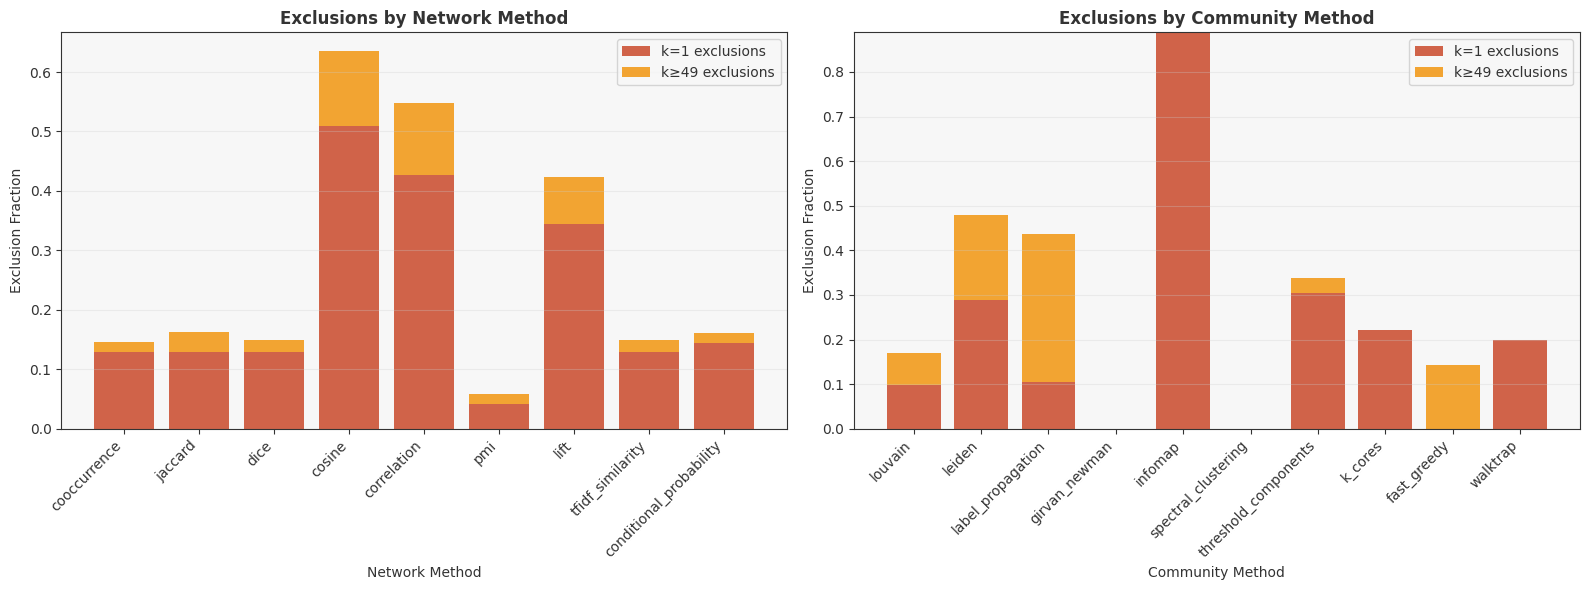

\nApplying exclusion filter: keeping 2 ≤ k ≤ 48
Results after exclusion: 6191 (removed 2145)
Retention rate: 74.3%


In [5]:
# %%

# =============================================================================
# 2 EXCLUSION ANALYSIS - METHODS FILTERED BY COMMUNITY COUNT
# =============================================================================

# run exclusion analysis and apply filter
analyzer.analyze_exclusions(COLORS)

\n=== FREQUENCY MATRIX WITH SURPRISAL WEIGHTING ===
\n=== SURPRISAL WEIGHTING COMPARISON ===
aggregating all results with surprisal weighting...
processing 6191 clusterings for 49 outlets (all_methods)
\n=== SURPRISAL WEIGHTING DIAGNOSTICS (all_methods) ===
Surprisal weighting: disabled
Total clusterings processed: 6191
Total weight sum: 2956840.00
Surprisal weight range: 1.00 to 1.00
Mean surprisal weight: 1.00
Median surprisal weight: 1.00
Cluster size distribution:
  Size 1: 36085 clusters
  Size 2: 3079 clusters
  Size 3: 2511 clusters
  Size 4: 1994 clusters
  Size 5: 2283 clusters
  Size 6: 1638 clusters
  Size 7: 1286 clusters
  Size 8: 1111 clusters
  Size 9: 837 clusters
  Size 10: 892 clusters
  Size 11: 804 clusters
  Size 12: 598 clusters
  Size 13: 573 clusters
  Size 14: 483 clusters
  Size 15: 358 clusters
  Size 16: 270 clusters
  Size 17: 245 clusters
  Size 18: 163 clusters
  Size 19: 163 clusters
  Size 20: 189 clusters
  Size 21: 203 clusters
  Size 22: 194 clusters

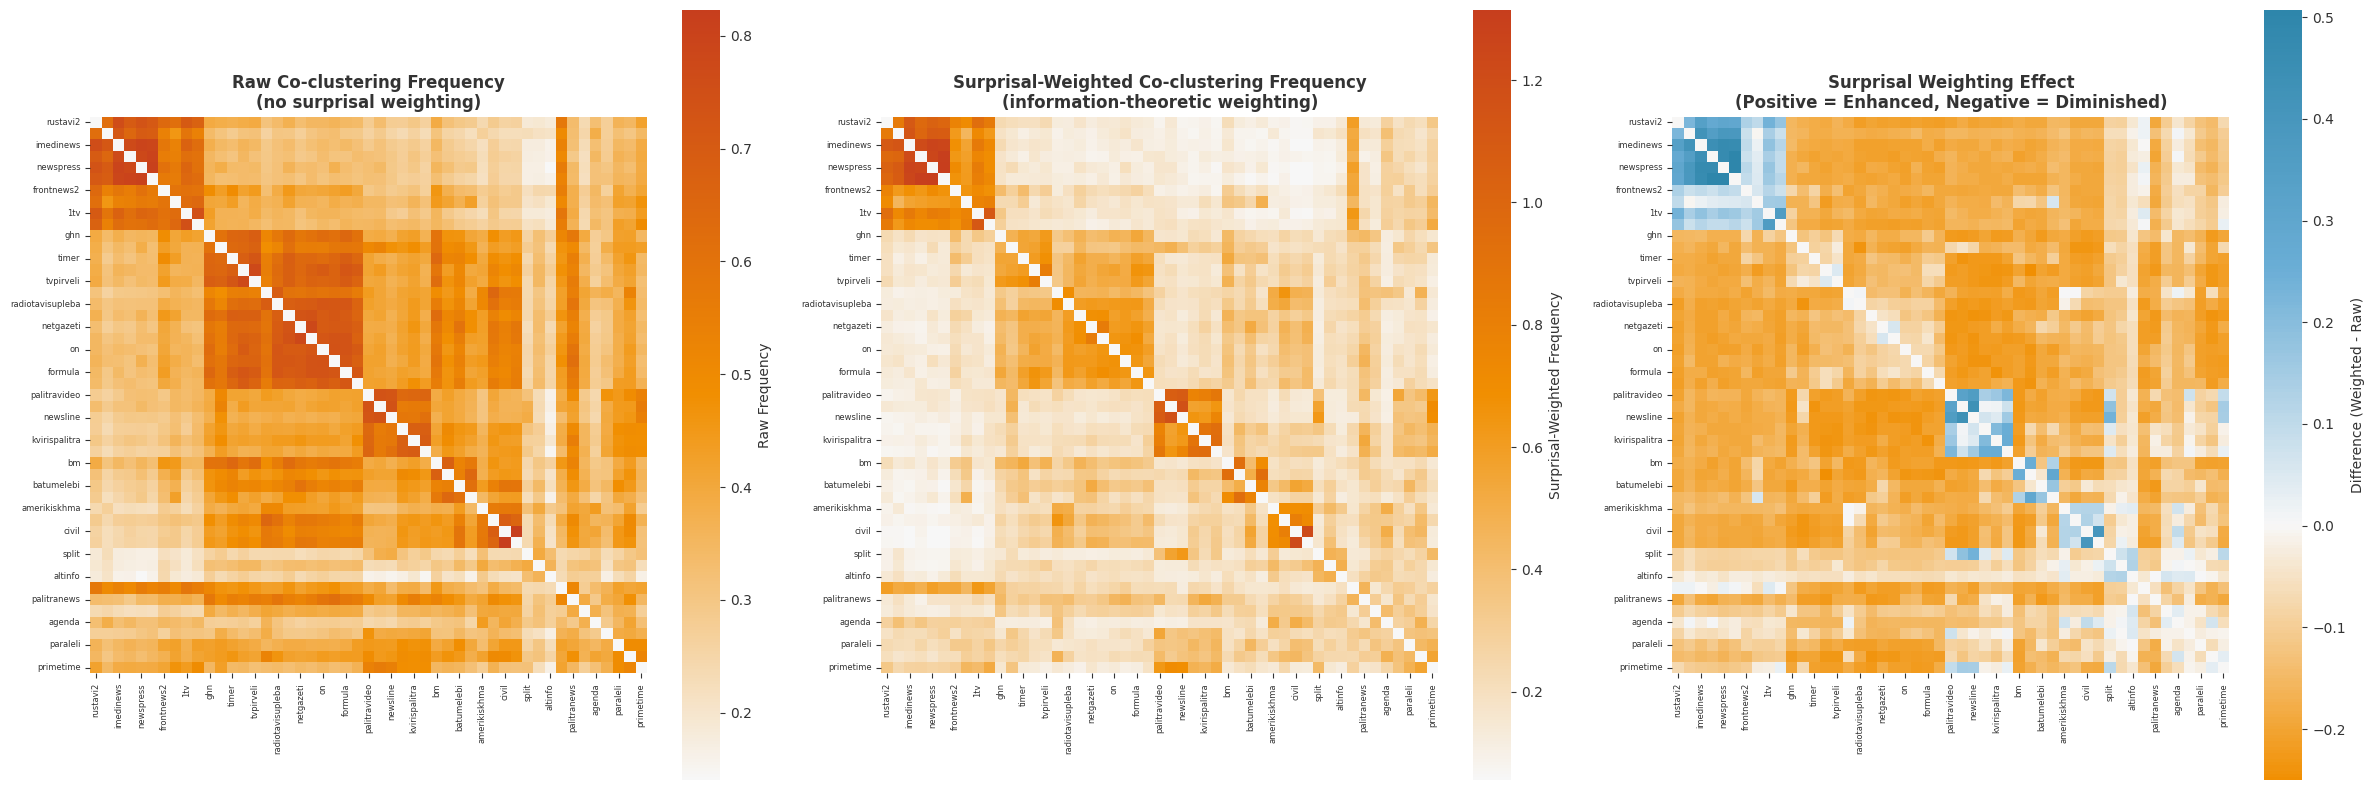


SURPRISAL WEIGHTING COMPARISON STATISTICS:
Raw frequency matrix:
  Mean: 0.4061
  Std:  0.1342
  Max:  0.8230
  Non-zero entries: 2352

Surprisal-weighted frequency matrix:
  Mean: 0.2857
  Std:  0.2027
  Max:  1.3145
  Non-zero entries: 2352

Difference (weighted - raw):
  Mean: -0.1204
  Std:  0.1115
  Range: [-0.2500, 0.5070]


In [9]:
# %%

# =============================================================================
# 3. FREQUENCY MATRIX WITH SURPRISAL WEIGHTING
# =============================================================================

print("\\n=== FREQUENCY MATRIX WITH SURPRISAL WEIGHTING ===")

# use analyzer method for surprisal weighting comparison
surprisal_results = analyzer.analyze_surprisal_weighting_comparison(COLORS)

# extract results for further use
frequency_matrix_raw = surprisal_results['frequency_matrix_raw']
frequency_matrix_weighted = surprisal_results['frequency_matrix_weighted']

# recreate variables needed for later sections
off_diag_mask = ~np.eye(frequency_matrix_raw.shape[0], dtype=bool)
freq_values = frequency_matrix_weighted.values[off_diag_mask]
max_freq = freq_values.max() if (freq_values > 0).any() else 1.0

if max_freq > 0:
    norm_freq = frequency_matrix_weighted / max_freq
else:
    norm_freq = frequency_matrix_weighted.copy()
np.fill_diagonal(norm_freq.values, 1.0)

# use surprisal-weighted frequencies for significance testing
frequency_matrix = frequency_matrix_weighted

\n=== SIGNIFICANCE ACROSS SAMPLES ANALYSIS ===

=== SIGNIFICANCE ACROSS SAMPLES ===
Processing 16 samples
Processing sample win_00: 362 runs
processing 362 clusterings for 49 outlets (sample_win_00)
\n=== SURPRISAL WEIGHTING DIAGNOSTICS (sample_win_00) ===
Surprisal weighting: enabled
Total clusterings processed: 362
Total weight sum: 130632.16
Surprisal weight range: 0.03 to 4.61
Mean surprisal weight: 0.78
Median surprisal weight: 0.57
Cluster size distribution:
  Size 1: 1590 clusters
  Size 2: 228 clusters
  Size 3: 139 clusters
  Size 4: 117 clusters
  Size 5: 119 clusters
  Size 6: 95 clusters
  Size 7: 68 clusters
  Size 8: 64 clusters
  Size 9: 80 clusters
  Size 10: 63 clusters
  Size 11: 70 clusters
  Size 12: 50 clusters
  Size 13: 47 clusters
  Size 14: 36 clusters
  Size 15: 22 clusters
  Size 16: 12 clusters
  Size 17: 15 clusters
  Size 18: 9 clusters
  Size 19: 15 clusters
  Size 20: 16 clusters
  Size 21: 10 clusters
  Size 22: 6 clusters
  Size 23: 7 clusters
  Size 2

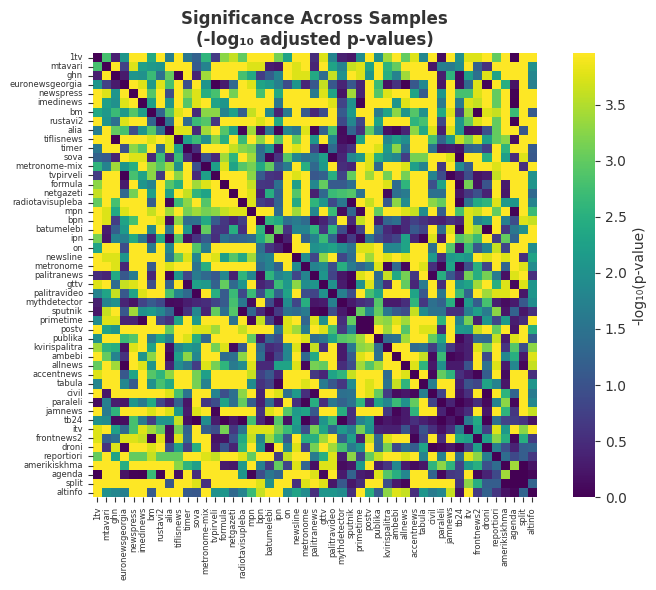

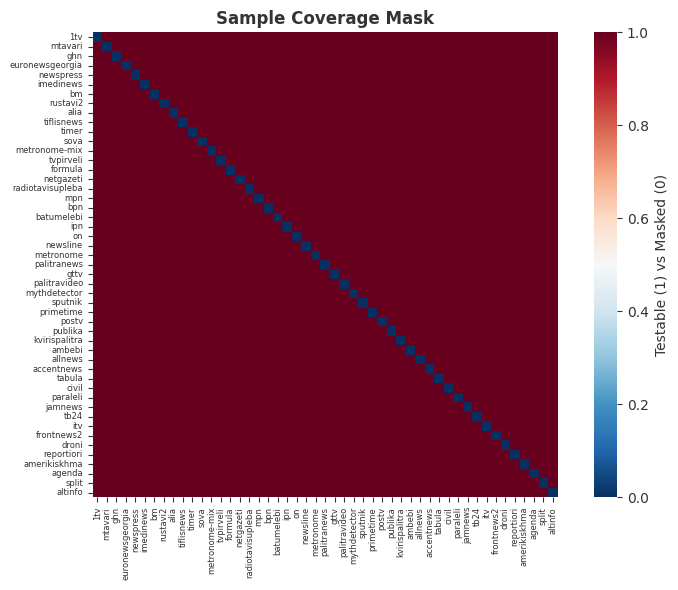

\nACROSS-SAMPLES SIGNIFICANCE RESULTS:
Analyzed 16 independent samples
High co-clustering pairs: 251
Low co-clustering pairs: 594
Masked pairs (insufficient coverage): 0


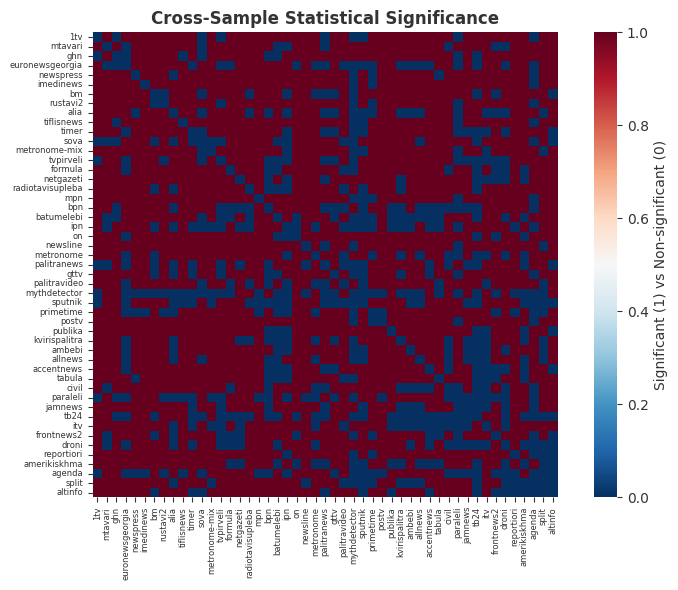

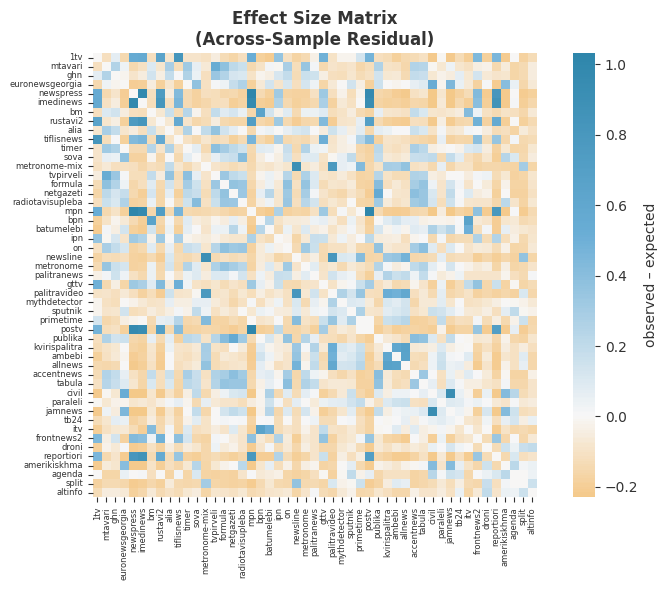

In [13]:
# %%

# =============================================================================
# 4. CROSS-SAMPLE STATISTICAL SIGNIFICANCE TESTING
# =============================================================================

print("\\n=== SIGNIFICANCE ACROSS SAMPLES ANALYSIS ===")

# Apply the analyze_significance_across_samples method
try:
    across_samples_results = analyzer.analyze_significance_across_samples(
        alpha=0.05,
        min_sample_frac=0.5,
        test="wilcoxon"
    )
    
    # Extract results and set as primary significance results
    high_pairs = across_samples_results['high_pairs'] 
    low_pairs = across_samples_results['low_pairs']
    p_adj_matrix_samples = across_samples_results['p_adj_matrix']
    n_samples = across_samples_results['n_samples']
    masked_pairs_samples = across_samples_results['masked_pairs']
    significant_mask = (p_adj_matrix_samples < 0.05).values
    
    print(f"\\nACROSS-SAMPLES SIGNIFICANCE RESULTS:")
    print(f"Analyzed {n_samples} independent samples")
    print(f"High co-clustering pairs: {len(high_pairs)}")
    print(f"Low co-clustering pairs: {len(low_pairs)}")
    print(f"Masked pairs (insufficient coverage): {len(masked_pairs_samples)}")
    
    # Show significance mask visualization
    plt.figure(figsize=(8, 6))
    sns.heatmap(significant_mask.astype(int), cmap='RdBu_r', center=0.5, square=True,
                cbar_kws={'label': 'Significant (1) vs Non-significant (0)'},
                xticklabels=analyzer.outlet_names, yticklabels=analyzer.outlet_names)
    plt.title('Cross-Sample Statistical Significance', fontweight='bold')
    plt.tick_params(axis='both', labelsize=6)
    plt.tight_layout()
    plt.savefig('results/cross_sample_significance.png', dpi=300, bbox_inches='tight')
    plt.show()

    # -------------------------------------------------------------
    # effect size (observed – expected) matrix visualisation
    # -------------------------------------------------------------
    effect_matrix = across_samples_results.get('effect_matrix')
    if effect_matrix is not None:
        plt.figure(figsize=(8, 6))
        sns.heatmap(effect_matrix, cmap=DIVERGING_CMAP, center=0, square=True,
                    xticklabels=analyzer.outlet_names, yticklabels=analyzer.outlet_names,
                    cbar_kws={'label': 'observed – expected'})
        plt.title('Effect Size Matrix\n(Across-Sample Residual)', fontweight='bold')
        plt.tick_params(axis='both', labelsize=6)
        plt.tight_layout()
        plt.savefig('results/effect_size_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()

except Exception as e:
    print(f"Cross-sample analysis failed: {e}")
    print("Cannot proceed without cross-sample significance results.")
    # Set empty results to prevent errors in downstream code
    high_pairs = []
    low_pairs = []
    significant_mask = np.zeros((len(analyzer.outlet_names), len(analyzer.outlet_names)), dtype=bool)


=== VALIDATED CLUSTERING (cross-sample significant edges) ===
\n=== CONSTRUCTING VALIDATED CLUSTERING ===
Constructed signed similarity matrix using 251 high and 594 low pairs
Successfully constructed 6 validated communities

Constructed 6 validated communities (cross-sample):
  Community 1 (10 outlets): 1tv, newspress, imedinews, rustavi2, tiflisnews, mpn, gttv, postv, frontnews2, reportiori
  Community 2 (14 outlets): mtavari, ghn, alia, timer, sova, tvpirveli, formula, netgazeti, radiotavisupleba, on, metronome, publika, accentnews, tabula
  Community 3 (7 outlets): metronome-mix, newsline, palitravideo, primetime, kvirispalitra, ambebi, allnews
  Community 4 (4 outlets): euronewsgeorgia, civil, jamnews, amerikiskhma
  Community 5 (4 outlets): bm, bpn, batumelebi, itv
  Community 6 (10 outlets): ipn, palitranews, mythdetector, sputnik, paraleli, tb24, droni, agenda, split, altinfo


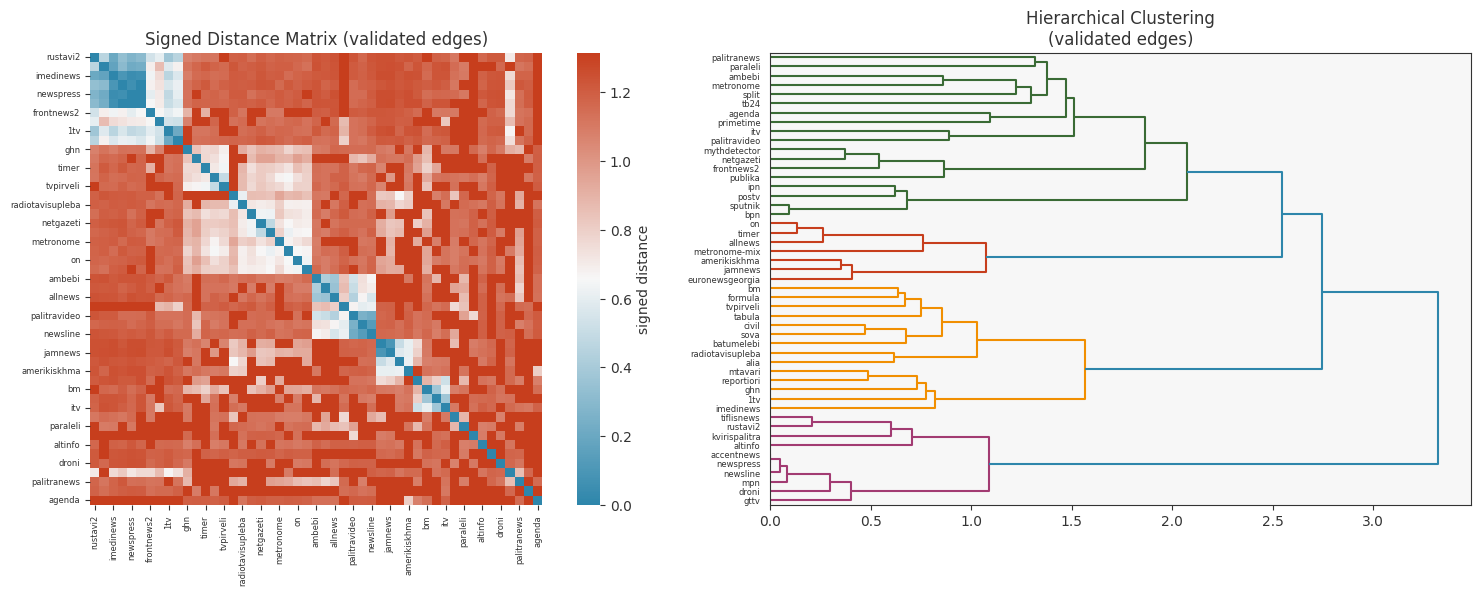

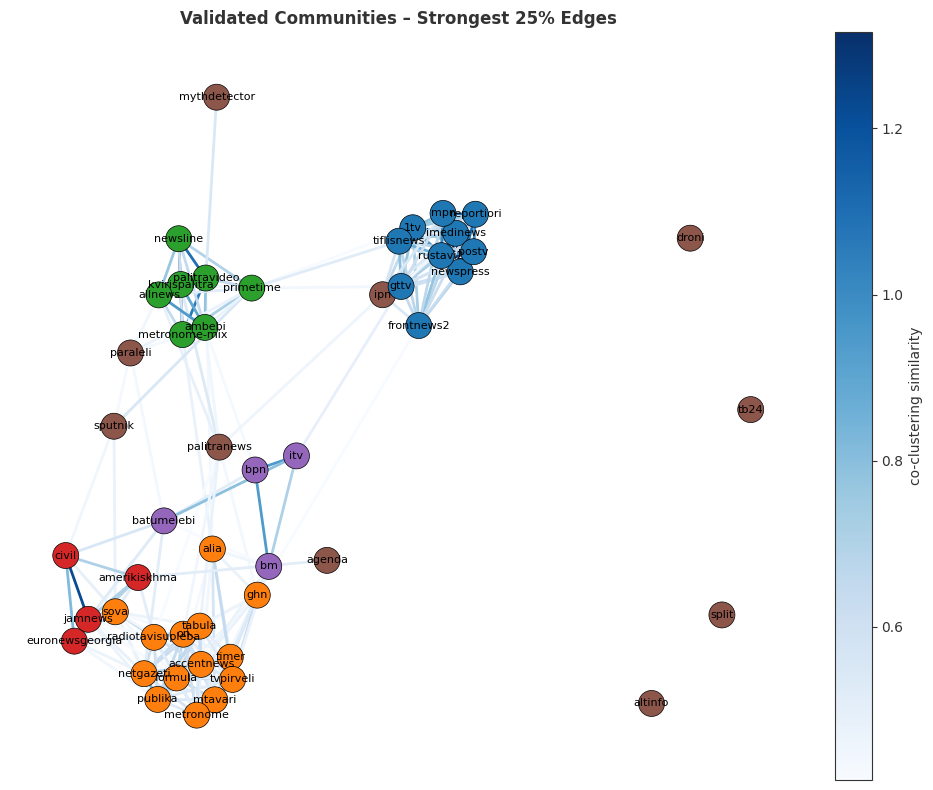


Consensus similarity statistics:
  Median within-community IPA: 0.571 (IQR 0.395–0.707)
  Median between-community IPA: 0.126
  Signed modularity Q: 0.343
  Elbow criterion suggests k* = 2


In [14]:
# %%

# =============================================================================
# 5. VALIDATED CLUSTERING FROM CROSS-SAMPLE SIGNIFICANCE
# =============================================================================

print("\n=== VALIDATED CLUSTERING (cross-sample significant edges) ===")

validated_across = analyzer.construct_validated_clustering(
    high_pairs=high_pairs,
    low_pairs=low_pairs,
    null_mean=0.0,  # baseline similarity for non-validated pairs
    null_std=0.0,
    n_clusters=None,
)

if validated_across and 'labels' in validated_across:
    Z_valid = validated_across['linkage']
    communities_valid = validated_across['communities']
    dist_valid = validated_across['distance_matrix']
    sim_valid = validated_across.get('similarity_matrix')

    print(f"\nConstructed {len(communities_valid)} validated communities (cross-sample):")
    for cid, members in sorted(communities_valid.items()):
        print(f"  Community {cid} ({len(members)} outlets): {', '.join(members)}")

    # visualise dendrogram + ordered distance heatmap
    try:
        order = leaves_list(Z_valid)
        ordered_dist = pd.DataFrame(dist_valid, index=analyzer.outlet_names,
                                    columns=analyzer.outlet_names).iloc[order, order]

        cmap_signed = LinearSegmentedColormap.from_list('signed_cmap',
                                                        ['#2E86AB', '#F7F7F7', '#C73E1D'], N=256)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        sns.heatmap(ordered_dist, cmap=cmap_signed, square=True, ax=axes[0],
                    cbar_kws={'label': 'signed distance'})
        axes[0].set_title('Signed Distance Matrix (validated edges)')
        axes[0].tick_params(axis='both', labelsize=6)

        dendrogram(Z_valid, labels=[analyzer.outlet_names[i] for i in order],
                    orientation='right', leaf_font_size=6, ax=axes[1])
        axes[1].set_title('Hierarchical Clustering\n(validated edges)')

        plt.tight_layout()
        os.makedirs('results', exist_ok=True)
        plt.savefig('results/final_validated_consensus_signed.png', dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Visualisation failed: {e}")

    # ---------------------------------------------------------
    # Graph visualisation – strongest validated edges
    # ---------------------------------------------------------
    try:
        if sim_valid is not None:
            # determine threshold for strongest edges (top 5% of all off-diagonal similarities)
            triu_idx = np.triu_indices_from(sim_valid, k=1)
            sim_vals = sim_valid[triu_idx]
            # consider only positive similarities for thresholding to avoid diluting with low/negative values
            sim_vals_pos = sim_vals[sim_vals > 0]

            if sim_vals_pos.size > 0:
                threshold = np.percentile(sim_vals_pos, 75)
            else:
                threshold = None

            # if threshold yields too few edges, iteratively relax criterion
            n_out = len(analyzer.outlet_names)
            min_edges_target = max(10, n_out // 2)  # aim for at least this many edges
            if threshold is not None:
                for pct in [85, 80, 75, 70]:
                    # quick check without building full graph yet
                    if np.sum(sim_vals_pos >= threshold) >= min_edges_target:
                        break
                    threshold = np.percentile(sim_vals_pos, pct)

            # build graph with only strong edges
            G_strong = nx.Graph()
            label_map = {outlet: cid for cid, members in communities_valid.items() for outlet in members}

            # add nodes with community metadata
            for outlet in analyzer.outlet_names:
                G_strong.add_node(outlet, community=label_map.get(outlet, -1))

            # add edges above threshold
            if threshold is not None:
                for i in range(n_out):
                    for j in range(i + 1, n_out):
                        w = sim_valid[i, j]
                        if w >= threshold:
                            G_strong.add_edge(analyzer.outlet_names[i], analyzer.outlet_names[j], weight=w)

            # skip visualisation if graph has no edges
            if G_strong.number_of_edges() > 0:
                fig, ax_graph = plt.subplots(figsize=(10, 8))

                # layout – spring layout seeded for reproducibility
                pos = nx.spring_layout(G_strong, seed=42, k=0.3)

                # node colors by community
                palette = sns.color_palette("tab10", n_colors=max(communities_valid.keys()))
                node_colors = [palette[label_map.get(node, 0)-1] if label_map.get(node, 0) > 0 else (0.7, 0.7, 0.7) for node in G_strong.nodes()]

                # edge colors scaled by weight
                edge_weights = [G_strong[u][v]['weight'] for u, v in G_strong.edges()]
                if edge_weights:
                    norm = plt.Normalize(min(edge_weights), max(edge_weights))
                    edge_colors = [plt.cm.Blues(norm(w)) for w in edge_weights]
                else:
                    edge_colors = 'grey'

                nx.draw_networkx_nodes(G_strong, pos, node_color=node_colors, node_size=350, edgecolors='black', linewidths=0.5, ax=ax_graph)
                nx.draw_networkx_edges(G_strong, pos, edge_color=edge_colors, width=2, ax=ax_graph)
                nx.draw_networkx_labels(G_strong, pos, font_size=8, ax=ax_graph)

                # colour bar for edge weights, if edges exist
                if edge_weights:
                    sm = plt.cm.ScalarMappable(cmap='Blues', norm=norm)
                    sm.set_array([])
                    fig.colorbar(sm, ax=ax_graph, label='co-clustering similarity')

                ax_graph.set_axis_off()
                ax_graph.set_title('Validated Communities – Strongest 25% Edges', fontweight='bold')
                fig.tight_layout()
                fig.savefig('results/final_validated_consensus_graph.png', dpi=300, bbox_inches='tight')
                plt.show()
            else:
                print("  No edges exceed the strength threshold – graph not displayed")
    except Exception as e:
        print(f"  Graph visualisation failed: {e}")

    # ---------------------------------------------------------
    # Consensus statistics (within / between IPA)
    # ---------------------------------------------------------
    if sim_valid is not None:
        n_out = len(analyzer.outlet_names)
        label_map = {}
        for cid, members in communities_valid.items():
            for m in members:
                label_map[m] = cid

        within_vals = []
        between_vals = []
        for i in range(n_out):
            for j in range(i + 1, n_out):
                val = sim_valid[i, j] if isinstance(sim_valid, np.ndarray) else sim_valid.iloc[i, j]
                if label_map[analyzer.outlet_names[i]] == label_map[analyzer.outlet_names[j]]:
                    within_vals.append(val)
                else:
                    between_vals.append(val)

        if within_vals and between_vals:
            w_median = np.median(within_vals)
            w_q1, w_q3 = np.percentile(within_vals, [25, 75])
            b_median = np.median(between_vals)
            print("\nConsensus similarity statistics:")
            print(f"  Median within-community IPA: {w_median:.3f} (IQR {w_q1:.3f}–{w_q3:.3f})")
            print(f"  Median between-community IPA: {b_median:.3f}")

    # ---------------------------------------------------------
    # Signed modularity of validated graph
    # ---------------------------------------------------------
    try:
        sim_pos = np.clip(sim_valid, 0, None) if sim_valid is not None else None
        if sim_pos is not None:
            G_mod = nx.from_numpy_array(sim_pos)
            partition = [set() for _ in communities_valid]
            for cid, members in communities_valid.items():
                for outlet in members:
                    idx = analyzer.outlet_names.index(outlet)
                    partition[cid-1].add(idx)
            partition = [p for p in partition if p]
            if len(partition) > 1:
                Q_signed = nx.community.modularity(G_mod, partition, weight='weight')
                print(f"  Signed modularity Q: {Q_signed:.3f}")
    except Exception as e:
        print(f"  Modularity calculation failed: {e}")

    # ---------------------------------------------------------
    # Elbow criterion – suggest k*
    # ---------------------------------------------------------
    try:
        distances = Z_valid[:, 2]
        diffs = np.diff(distances, prepend=distances[0])
        elbow_idx = np.argmax(diffs)
        k_star = len(analyzer.outlet_names) - elbow_idx
        print(f"  Elbow criterion suggests k* = {k_star}")
    except Exception as e:
        print(f"  Elbow analysis failed: {e}")

else:
    print("No validated clustering could be constructed (no significant edges)")